# Running Pace & Heart Rate Analysis

This notebook analyses `.fit` files (Garmin/COROS activity exports) to study the
relationship between **pace** (and **effort pace**) and **heart rate (HR)**.

## What this notebook does

1. **Section 1** — Load one or more `.fit` files and extract raw records.
2. **Section 2** — For each file:
   - 2.1: extract per-timestamp GPS pace, effort pace, and HR
   - 2.2: compute centred rolling averages of these metrics
   - 2.3: plot HR vs (averaged) GPS pace, and HR vs (averaged) effort pace, over time
   - 2.4: estimate **τ\* (tau-star)**, the time lag between a pace change and the
     corresponding HR response, via cross-correlation
3. **Section 3** — Combine all files into pace-vs-HR and effort-pace-vs-HR scatter
   plots, with mean HR ± 95% CI per pace bin, optionally corrected for τ\*.

## Key concepts

- **GPS pace**: derived from `speed` (m/s) → converted to min/km.
- **Effort pace**: derived from the device's `"Effort Pace"` field (m/s) → converted
  to min/km. This is the device's own effort-adjusted pace estimate (e.g. accounting
  for elevation), distinct from raw GPS pace.
- **Centred rolling average**: for point `i`, the average of a metric over
  `[i - n, i + n]` (n samples on *each* side). This is symmetric in index space, so
  it does not introduce a time lag/shift the way a backward-only average would.
- **τ\* (tau-star)**: HR responds to a pace change with a physiological delay
  (cardiovascular lag). τ\* is the lag (in seconds) that **maximises** the
  cross-correlation between HR and pace. A positive τ\* means HR lags pace by that
  many seconds. Applying this correction means: at time `t`, we compare `HR(t)`
  with `pace(t − τ*)` — i.e. *the pace that was set τ\* seconds ago* — which should
  give a cleaner, less noisy pace-vs-HR relationship.
- **Abrupt pace-change filter**: discards a data point if its pace deviates more
  than `abrupt_x`% from the mean pace of the previous `abrupt_n` *valid* points.
  This removes sudden spikes (traffic lights, GPS glitches) that would otherwise
  corrupt both the τ\* estimate and the scatter plots — both now use **the same
  filtered, abrupt-change-free data**.

## Main adjustable parameters

| Parameter | Where | Meaning |
|---|---|---|
| `average_n` | Section 2.2 | half-width (in samples) of the centred rolling average |
| `abrupt_n`, `abrupt_x` | Sections 2.4 / 3 | abrupt pace-change filter settings |
| `max_lag_seconds` | Section 2.4 | range of lags (s) searched when estimating τ\* |
| `apply_tau_correction` | Section 3 | whether to shift pace by each file's τ\* before plotting |
| `pace_min`, `pace_max`, `pace_bin` | Section 3 | scatter plot pace-axis range and bin width |

## Fixes applied vs. the previous script version

- **τ\* estimation now uses the same abrupt-pace-filtered data** as the scatter
  plots (previously it used raw, unfiltered records — inconsistent with the rest
  of the pipeline).
- **`apply_tau_correction` is now an explicit boolean**, separate from the τ\*
  value itself, so a legitimate `τ* = 0` is never silently treated as "off"
  (previously `tau_star=False`/`None` was overloaded and ambiguous).
- Cross-correlation and rolling-average logic are no longer duplicated across
  functions — there is a single source of truth for each computation.


## Section 1 — Setup & loading `.fit` files

Run the imports below, then list the paths to your `.fit` files in `fit_files`.


In [126]:
import warnings
import fitdecode
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")


def load_records(fit_path):
    '''Load all 'record' messages from a single .fit file as a list of dicts.'''
    records = []
    with fitdecode.FitReader(fit_path) as fit:
        for frame in fit:
            if isinstance(frame, fitdecode.FitDataMessage) and frame.name == "record":
                r = {f.name: f.value for f in frame.fields}
                records.append(r)
    return records


def speed_to_pace(speed_ms):
    '''Convert speed (m/s) to pace (min/km).'''
    return (1000 / speed_ms) / 60


def format_elapsed(x, _):
    '''Tick formatter: seconds -> mm:ss'''
    m, s = divmod(int(max(x, 0)), 60)
    return f"{m}:{s:02d}"


def format_pace(x, _):
    '''Tick formatter: decimal minutes -> m:ss (for pace axes)'''
    m = int(x)
    s = int(round((x - m) * 60))
    return f"{m}:{s:02d}"


def hr_zones():
    '''Fixed HR zone boundaries (bpm) used to shade plots.'''
    return [
        (0,   133, "#d4edff", "Z1 (Recovery)"),
        (133, 157, "#b3f0b3", "Z2 (Aerobic endurance)"),
        (157, 165, "#fff3b3", "Z3 (Tempo)"),
        (165, 175, "#ffd9b3", "Z4 (Threshold)"),
        (175, 192, "#ffb3b3", "Z5 (VO2)"),
    ]


def rolling_avg(values, window=10):
    '''Simple backward-looking rolling average (used only for HR display smoothing).'''
    return [
        sum(values[max(0, i - window):i + 1]) / len(values[max(0, i - window):i + 1])
        for i in range(len(values))
    ]


def apply_dark_style(ax, fig):
    fig.patch.set_facecolor("#f8f8f5")
    ax.set_facecolor("#f8f8f5")
    ax.tick_params(colors="#333333")
    for spine in ax.spines.values():
        spine.set_edgecolor("#bbbbbb")


In [127]:
# List your .fit file paths here
fit_files = [
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Running_Fitness_Test2026_06_10.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Saint-Gilles_jog_2026_06_12.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Madrid_VO2_3_2026_06_15.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\LT2_4×5_2026_06_17.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Madrid_cotes_2026_06_19.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Boulogne_10k_progressif_2026_07_20.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Madrid_jog_2026_07_26.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Madrid_10k_lent_canicule_2026_07_27.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Paris_progressif_10k_2026_08_02.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Nantes_6k_tres_lent_2026_08_05.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\VMA_3_SG_2026_08_07.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_progressif_2026_08_09.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_vers_Sion_31deg_2026_08_11.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_LT2_4×5_2026_08_13.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_90pVMA_4×42026_08_17.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_jog_2026_08_19.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_jog_2026_08_20.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_variation_allure_6×1km_2026_08_21.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_LT2_4x7min_2026_08_24.fit",
    r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_lactate_shuffle_27_08_2026.fit",
    
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23106929328_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23215254195_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23497207141_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23514813395_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23527016413_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23549772938_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23667998935_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23727803436_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23767488808_ACTIVITY.fit",
    # r"C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Strava Adrien\23860622480_ACTIVITY.fit",

]
print(f"{len(fit_files)} file(s) listed.")


9 file(s) listed.


## Section 2 — Per-file processing

For each file we build a small table of `(elapsed_seconds, gps_pace, effort_pace, heart_rate)`,
then compute rolling averages, plot the time series, and estimate τ\*.


### 2.1 — Extract GPS pace, effort pace, and HR per timestamp

`extract_metrics(fit_path)` returns a dict of equal-length lists:
`elapsed` (seconds since start), `gps_pace`, `effort_pace`, `hr`.

A timestamp is only included if it has a valid heart rate. `gps_pace` /
`effort_pace` are `None` for that timestamp if the underlying `speed` /
`"Effort Pace"` field is missing or non-positive (this is common for the
first second or two of a recording).


In [128]:
def extract_metrics(fit_path):
    '''
    Build a per-timestamp table of elapsed time, GPS pace, effort pace, and HR
    for a single .fit file.

    Returns a dict with keys: 'elapsed', 'gps_pace', 'effort_pace', 'hr'
    (all lists, same length, aligned by timestamp index, sorted by time).
    '''
    records = load_records(fit_path)

    rows = []
    for r in records:
        if "timestamp" not in r or "heart_rate" not in r or r["heart_rate"] is None:
            continue
        ts = r["timestamp"]
        hr = r["heart_rate"]

        speed = r.get("speed") or r.get("enhanced_speed")
        gps_pace = speed_to_pace(speed) if speed and speed > 0 else None
        ep = r.get("Effort Pace")
        effort_pace = speed_to_pace(ep) if ep and ep > 0 else None

        rows.append((ts, gps_pace, effort_pace, hr))

    rows.sort(key=lambda x: x[0])
    if not rows:
        return {"elapsed": [], "gps_pace": [], "effort_pace": [], "hr": []}

    t0 = rows[0][0]
    elapsed = [(ts - t0).total_seconds() for ts, _, _, _ in rows]
    gps_pace = [row[1] for row in rows]
    effort_pace = [row[2] for row in rows]
    hr = [row[3] for row in rows]

    return {"elapsed": elapsed, "gps_pace": gps_pace, "effort_pace": effort_pace, "hr": hr}


def print_metrics_table_head(metrics, fit_path, n=5):
    '''Pretty-print the first n rows of a metrics dict.'''
    print(f"\n{fit_path}")
    print(f"{'elapsed (s)':>12} | {'GPS pace':>10} | {'effort pace':>12} | {'HR':>5}")
    print("-" * 50)
    for i in range(min(n, len(metrics['elapsed']))):
        e = metrics['elapsed'][i]
        gp = metrics['gps_pace'][i]
        ep = metrics['effort_pace'][i]
        h = metrics['hr'][i]
        gp_str = f"{gp:.2f}" if gp is not None else "—"
        ep_str = f"{ep:.2f}" if ep is not None else "—"
        print(f"{e:12.1f} | {gp_str:>10} | {ep_str:>12} | {h:5d}")


In [129]:
# Extract and store metrics for every file
file_metrics = {}   # fit_path -> metrics dict (from extract_metrics)

for f in fit_files:
    file_metrics[f] = extract_metrics(f)
    print_metrics_table_head(file_metrics[f], f, n=5)



C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Nantes_6k_tres_lent_2026_08_05.fit
 elapsed (s) |   GPS pace |  effort pace |    HR
--------------------------------------------------
         0.0 |          — |            — |   127
         1.0 |          — |            — |   127
         2.0 |       5.86 |         5.87 |   127
         3.0 |       5.91 |         5.91 |   126
         4.0 |       5.99 |         6.00 |   126

C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\VMA_3_SG_2026_08_07.fit
 elapsed (s) |   GPS pace |  effort pace |    HR
--------------------------------------------------
         0.0 |          — |            — |   142
         1.0 |          — |            — |   142
         2.0 |       6.41 |         6.41 |   142
         3.0 |       6.41 |         6.41 |   142
         4.0 |       6.42 |         6.42 |   142

C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_progressif_2026_08_09.fit
 elapsed (s) |   GPS pace |  effort pace |    HR
--------

### 2.2 — Centred rolling average of each metric

`centred_rolling_average(values, n)` averages each point `i` over the window
`[i - n, i + n]` (truncated near the edges). This is applied independently to
GPS pace, effort pace, and HR.

`n` is a number of **samples**, not seconds — with COROS/Garmin data sampled at
~1 Hz, `n=30` corresponds to roughly a ±30 second window.


In [130]:
def centred_rolling_average(values, n):
    '''
    Centred rolling average: point i is averaged over [i-n, i+n] (in samples).
    None values are skipped; if a window contains only None, the result is None.

    Args:
        values : list of numbers or None
        n      : half-width of the window, in samples

    Returns:
        list of the same length as `values`.
    '''
    length = len(values)
    out = []
    for i in range(length):
        lo = max(0, i - n)
        hi = min(length, i + n + 1)
        window = [v for v in values[lo:hi] if v is not None]
        out.append(sum(window) / len(window) if window else None)
    return out


average_n = 30   # half-width in samples (~30s on each side at 1Hz sampling)

for f in fit_files:
    m = file_metrics[f]
    m["gps_pace_avg"] = centred_rolling_average(m["gps_pace"], average_n)
    m["effort_pace_avg"] = centred_rolling_average(m["effort_pace"], average_n)
    m["hr_avg"] = centred_rolling_average(m["hr"], average_n)

print(f"Rolling averages computed (average_n = {average_n} samples on each side).")
print_metrics_table_head(
    {"elapsed": file_metrics[fit_files[0]]["elapsed"],
     "gps_pace": file_metrics[fit_files[0]]["gps_pace_avg"],
     "effort_pace": file_metrics[fit_files[0]]["effort_pace_avg"],
     "hr": file_metrics[fit_files[0]]["hr"]},
    fit_files[0] + "  (gps_pace / effort_pace columns now show AVERAGED values)",
    n=5
)


Rolling averages computed (average_n = 30 samples on each side).

C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Nantes_6k_tres_lent_2026_08_05.fit  (gps_pace / effort_pace columns now show AVERAGED values)
 elapsed (s) |   GPS pace |  effort pace |    HR
--------------------------------------------------
         0.0 |       6.51 |         6.51 |   127
         1.0 |       6.52 |         6.53 |   127
         2.0 |       6.54 |         6.54 |   127
         3.0 |       6.55 |         6.55 |   126
         4.0 |       6.56 |         6.56 |   126


### 2.3 — Plot HR vs GPS pace, and HR vs effort pace, over time

Two functions, one per pace type. Each produces a single figure with:
- left axis: heart rate (raw + smoothed for display) with HR zone bands
- right axis (inverted, faster = up): raw pace (faint) + the centred rolling
  average computed in 2.2 (bold)


In [131]:
def _plot_hr_and_pace(elapsed, hr, pace_raw, pace_avg, pace_label, pace_color, title, save_path=None):
    '''Shared plotting logic for HR + a single pace series (GPS or effort).'''
    max_hr = max(hr)
    avg_hr = sum(hr) / len(hr)
    smoothed_hr = rolling_avg(hr)

    fig, ax_hr = plt.subplots(figsize=(14, 6))
    apply_dark_style(ax_hr, fig)

    for lo, hi, color, label in hr_zones():
        ax_hr.axhspan(lo, hi, alpha=0.22, color=color, label=label)

    ax_hr.plot(elapsed, hr, color="#ff6b6b", alpha=0.20, linewidth=0.8)
    ax_hr.plot(elapsed, smoothed_hr, color="#ff6b6b", linewidth=1.8, label="Heart Rate")
    ax_hr.axhline(avg_hr, color="#ff6b6b", linestyle="--", linewidth=1,
                  alpha=0.6, label=f"Avg HR: {avg_hr:.0f} bpm")

    max_idx = hr.index(max_hr)
    ax_hr.annotate(f"Max: {max_hr} bpm",
                   xy=(elapsed[max_idx], max_hr),
                   xytext=(elapsed[max_idx] + 60, max_hr + 3),
                   color="white", fontsize=9,
                   arrowprops=dict(arrowstyle="->", color="white", lw=0.8))

    ax_hr.set_ylabel("Heart Rate (bpm)", color="#ff6b6b", fontsize=11)
    ax_hr.set_ylim(50, max_hr + 15)
    ax_hr.set_xlim(0, elapsed[-1])
    ax_hr.tick_params(axis="y", colors="#ff6b6b")

    ax_pace = ax_hr.twinx()
    ax_pace.set_facecolor("none")
    ax_pace.tick_params(colors="#aaaaaa", axis="both")
    for spine in ax_pace.spines.values():
        spine.set_edgecolor("#333333")

    valid_raw = [(e, p) for e, p in zip(elapsed, pace_raw) if p is not None]
    if valid_raw:
        vx, vy = zip(*valid_raw)
        ax_pace.plot(vx, vy, color=pace_color, linewidth=0.8, alpha=0.35, label=pace_label)

    valid_avg = [(e, p) for e, p in zip(elapsed, pace_avg) if p is not None]
    if valid_avg:
        vx, vy = zip(*valid_avg)
        ax_pace.plot(vx, vy, color=pace_color, linewidth=2.0, alpha=0.90,
                     label=f"Avg {pace_label}")

    ax_pace.invert_yaxis()
    ax_pace.yaxis.set_major_formatter(ticker.FuncFormatter(format_pace))
    ax_pace.set_ylabel(f"{pace_label} (min/km)  —  faster \u2191", color=pace_color, fontsize=11)
    ax_pace.tick_params(axis="y", colors=pace_color)
    ax_pace.set_ylim(8, 3.5)

    ax_hr.xaxis.set_major_formatter(ticker.FuncFormatter(format_elapsed))
    ax_hr.xaxis.set_major_locator(ticker.MultipleLocator(300))
    ax_hr.set_xlabel("Elapsed time (mm:ss)", color="#aaaaaa", fontsize=11)

    handles_hr, labels_hr = ax_hr.get_legend_handles_labels()
    handles_pace, labels_pace = ax_pace.get_legend_handles_labels()
    ax_hr.legend(handles_hr + handles_pace, labels_hr + labels_pace,
                 loc="lower right", fontsize=8,
                 facecolor="#1c1f26", edgecolor="#444444", labelcolor="white")

    ax_hr.set_title(title, color="white", fontsize=14, pad=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved: {save_path}")
    plt.show()


def plot_run_stats(fit_path, save_path=None):
    '''HR + GPS pace (raw + averaged) over time, using metrics already stored in file_metrics.'''
    m = file_metrics[fit_path]
    _plot_hr_and_pace(m["elapsed"], m["hr"], m["gps_pace"], m["gps_pace_avg"],
                      pace_label="GPS Pace", pace_color="#7ec8e3",
                      title="Run Stats \u2014 HR & GPS Pace", save_path=save_path)


def plot_effortrun_stats(fit_path, save_path=None):
    '''HR + Effort pace (raw + averaged) over time, using metrics already stored in file_metrics.'''
    m = file_metrics[fit_path]
    _plot_hr_and_pace(m["elapsed"], m["hr"], m["effort_pace"], m["effort_pace_avg"],
                      pace_label="Effort Pace", pace_color="#f0a500",
                      title="Run Stats \u2014 HR & Effort Pace", save_path=save_path)


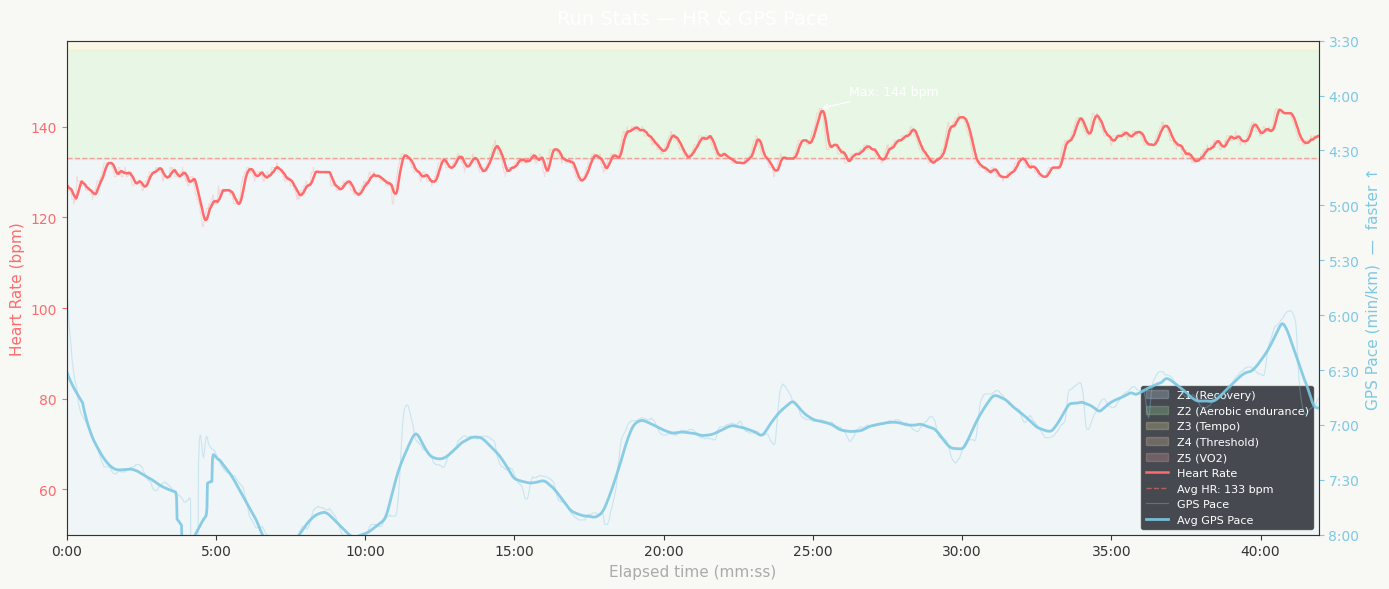

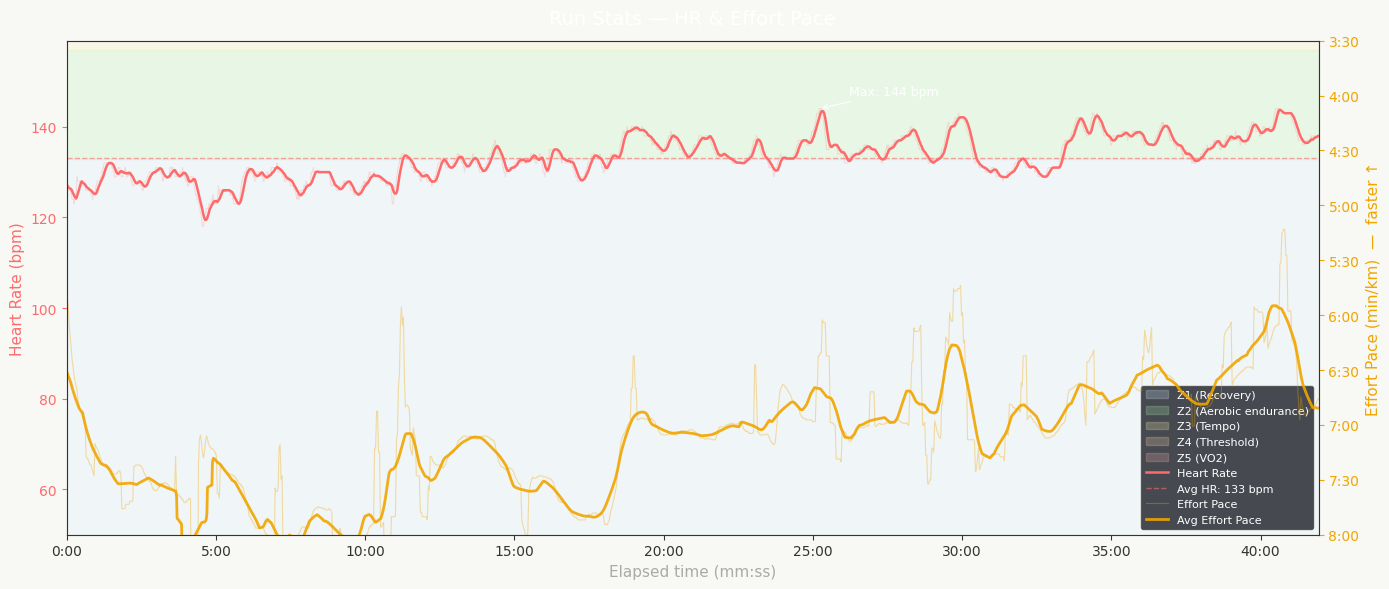

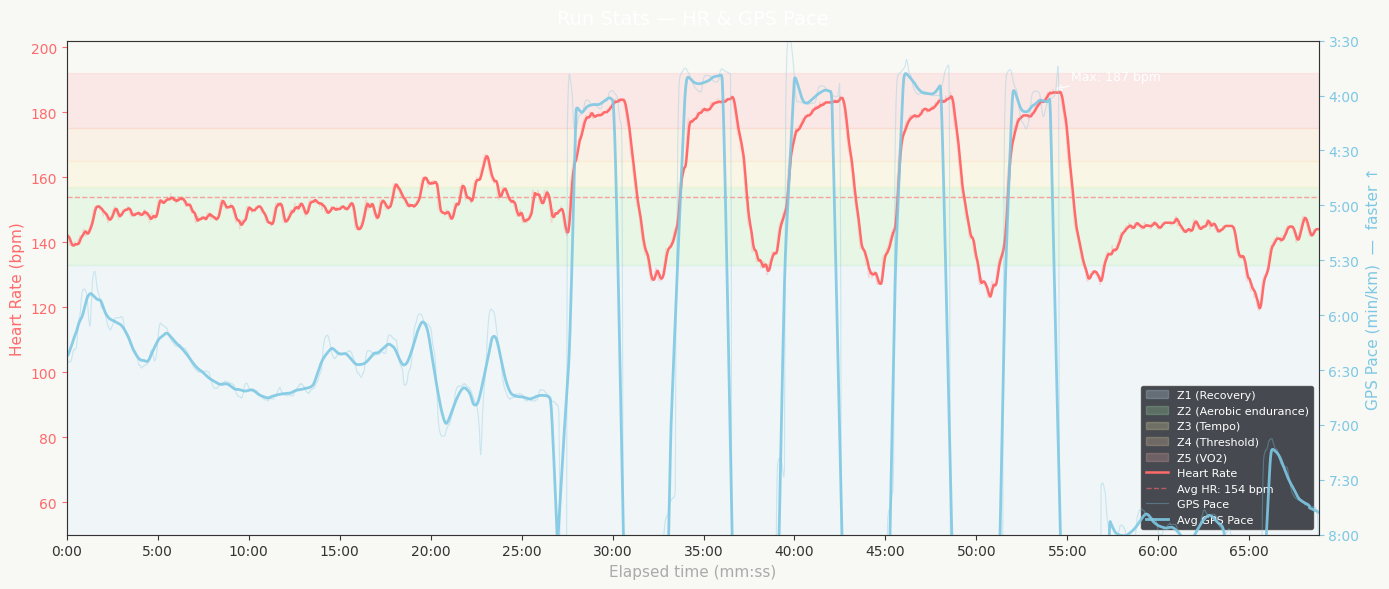

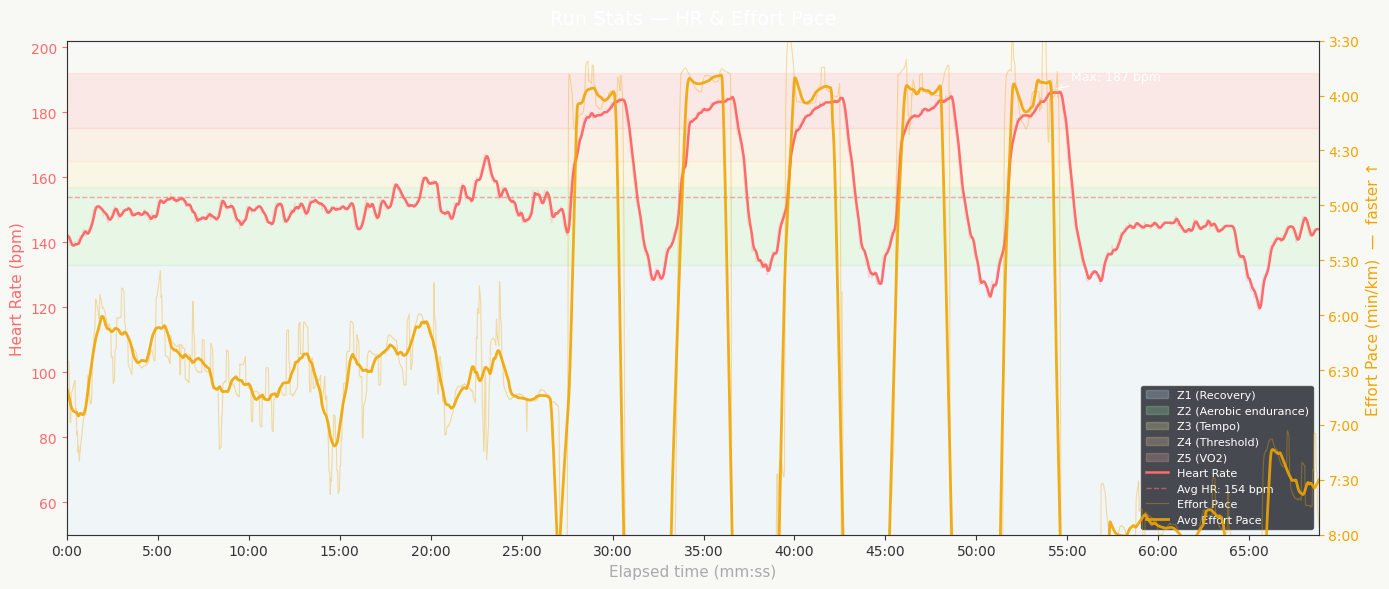

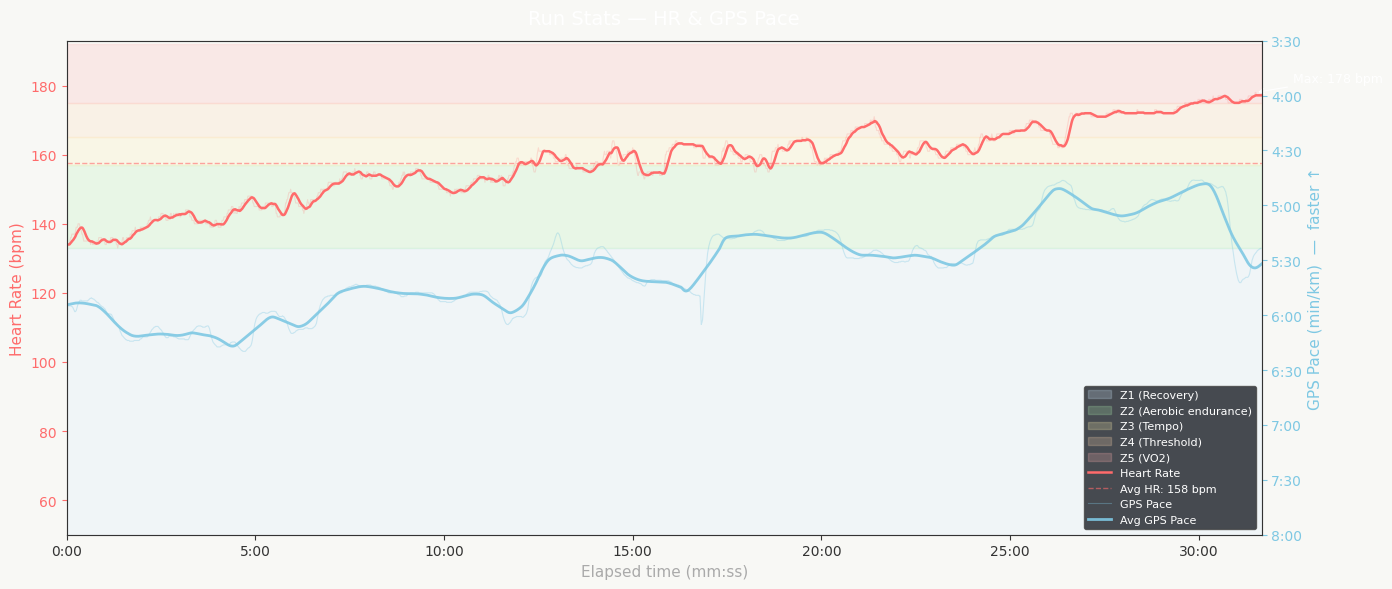

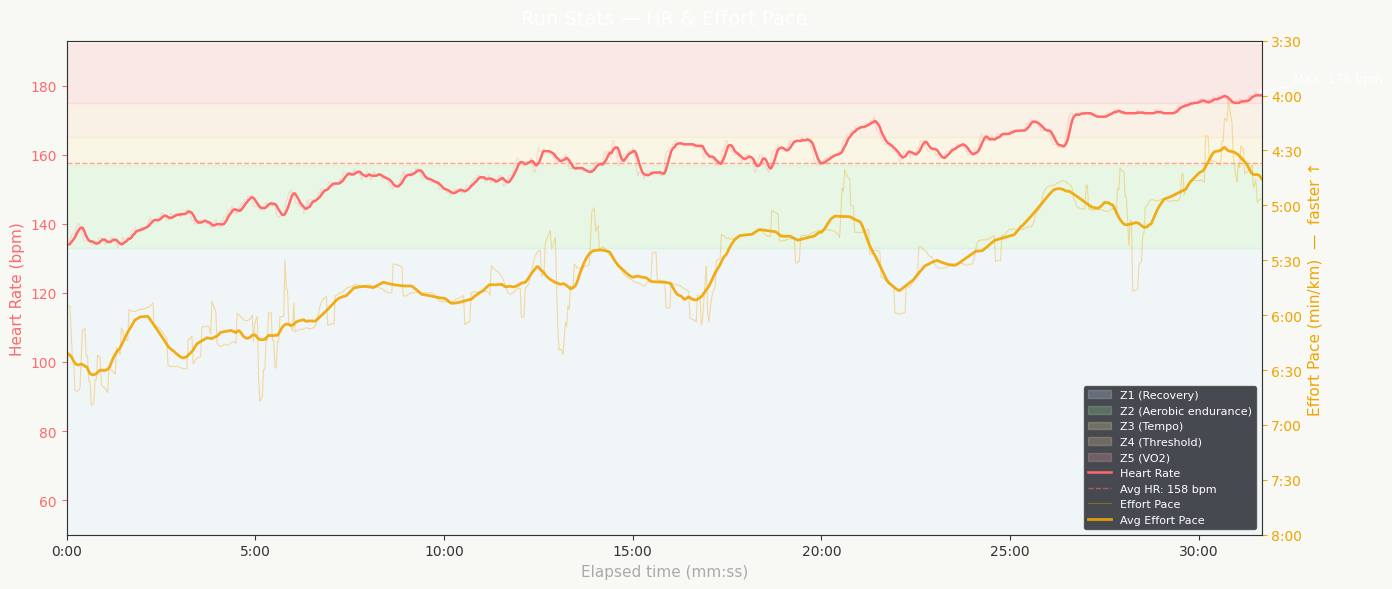

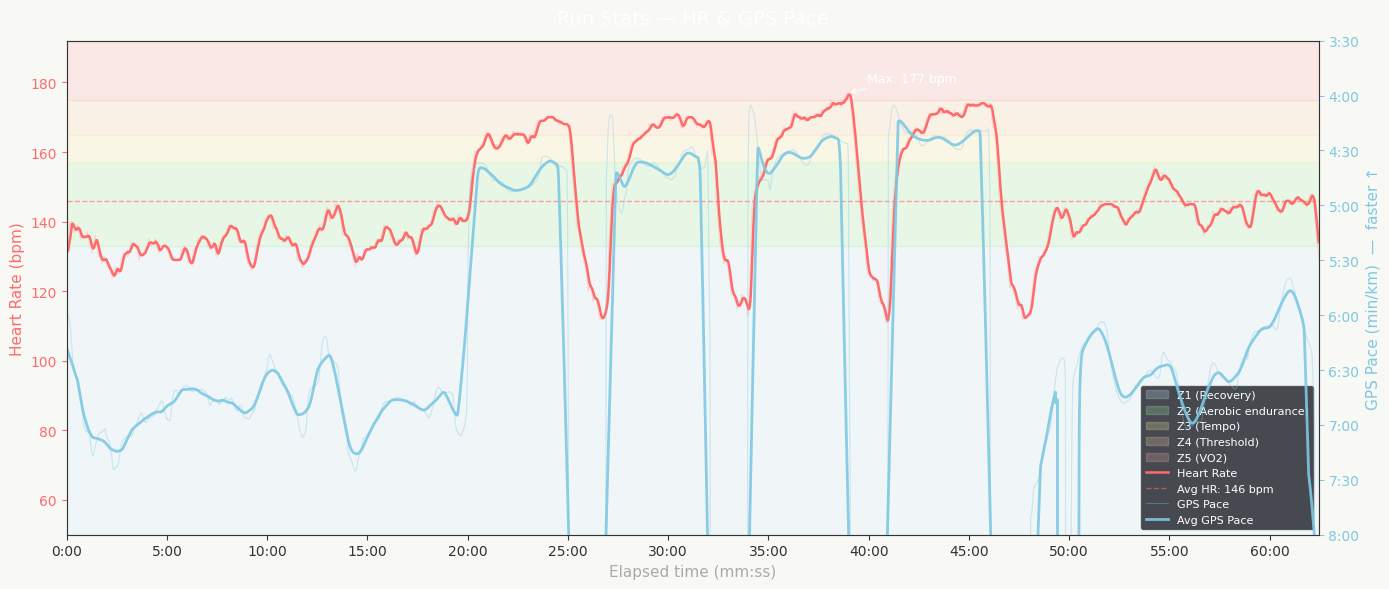

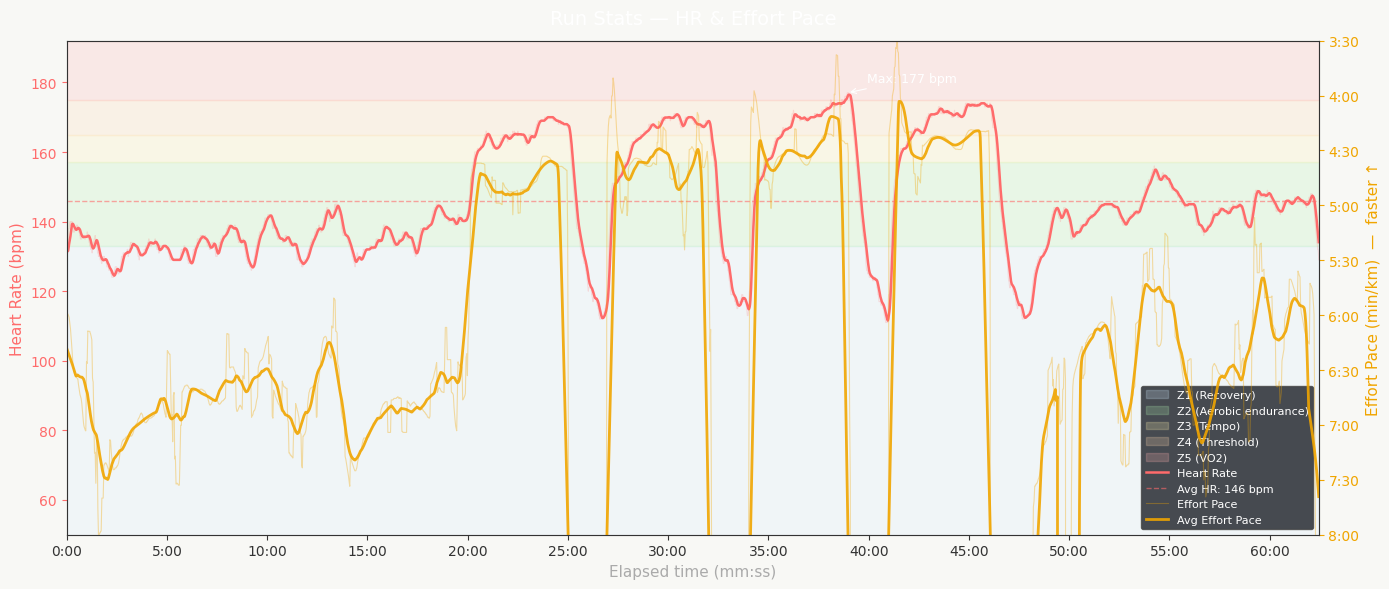

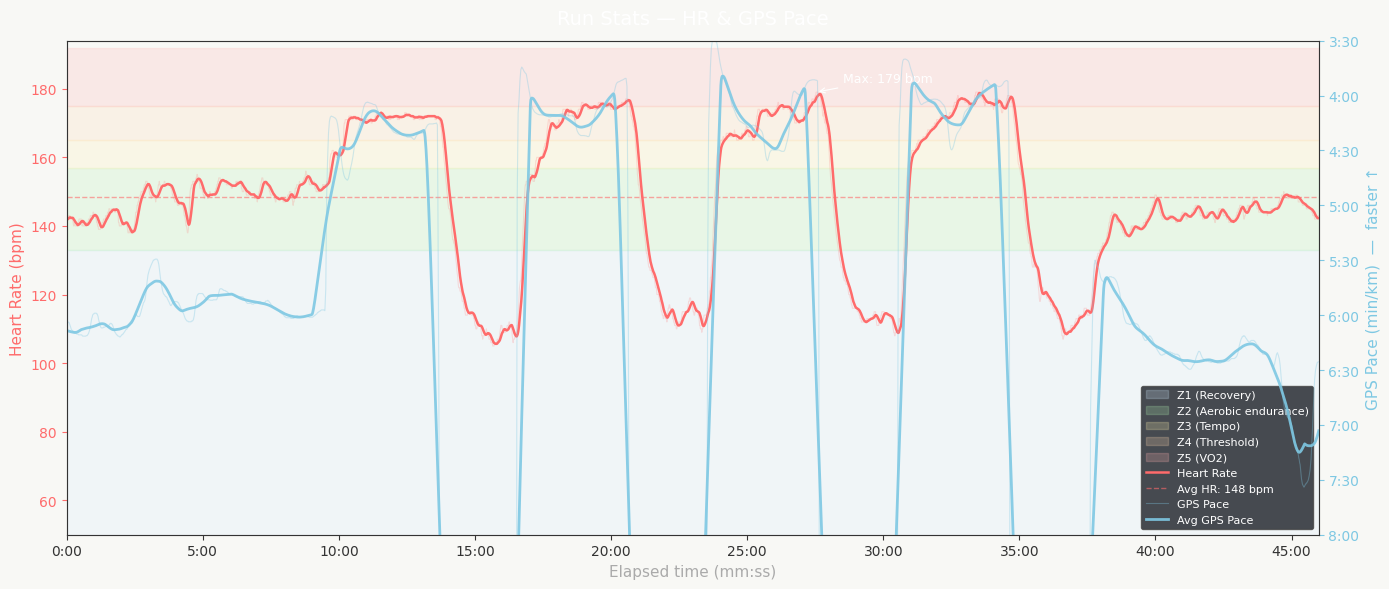

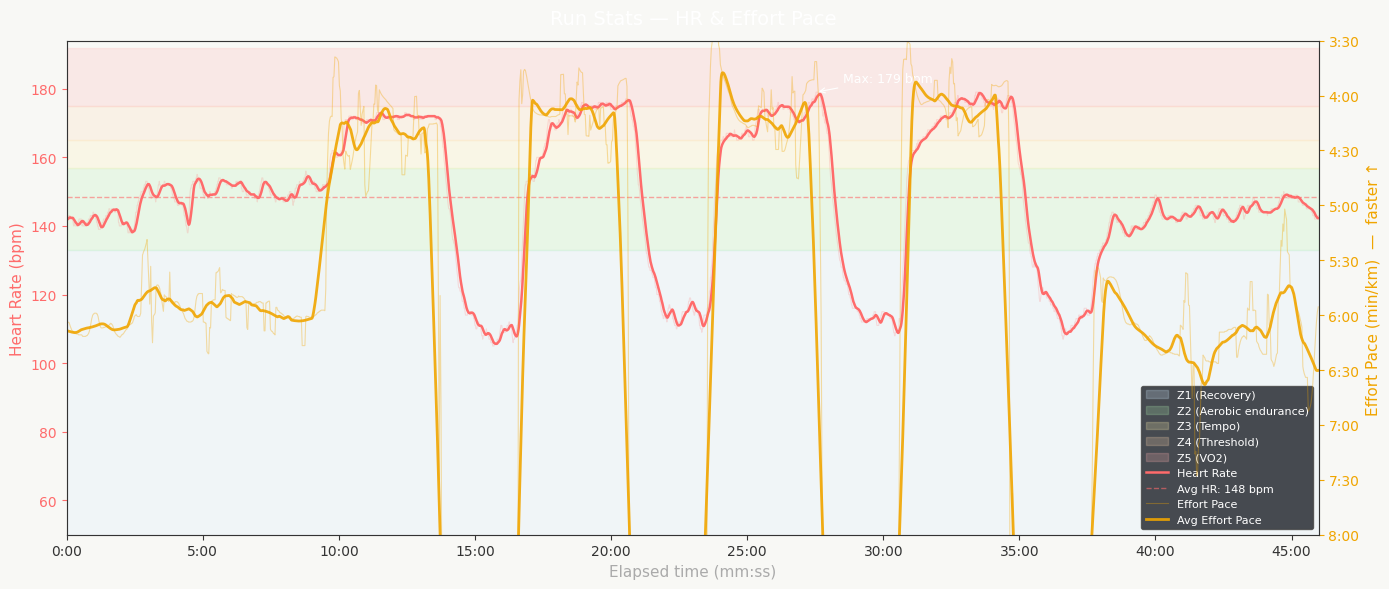

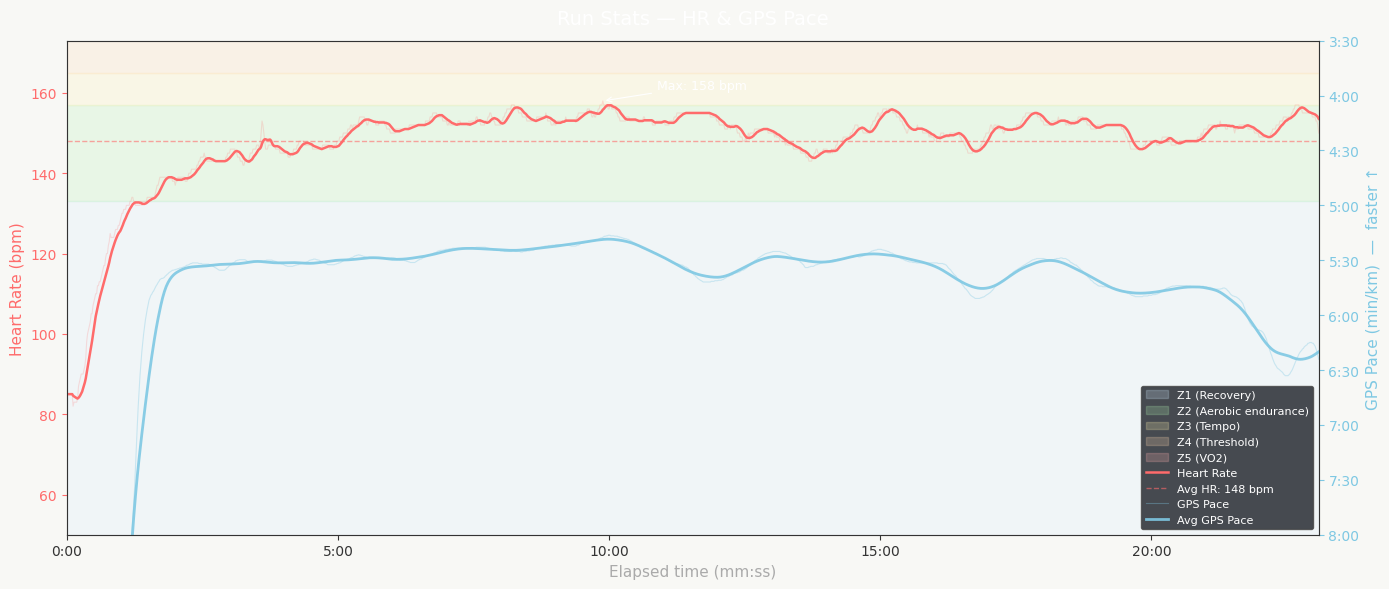

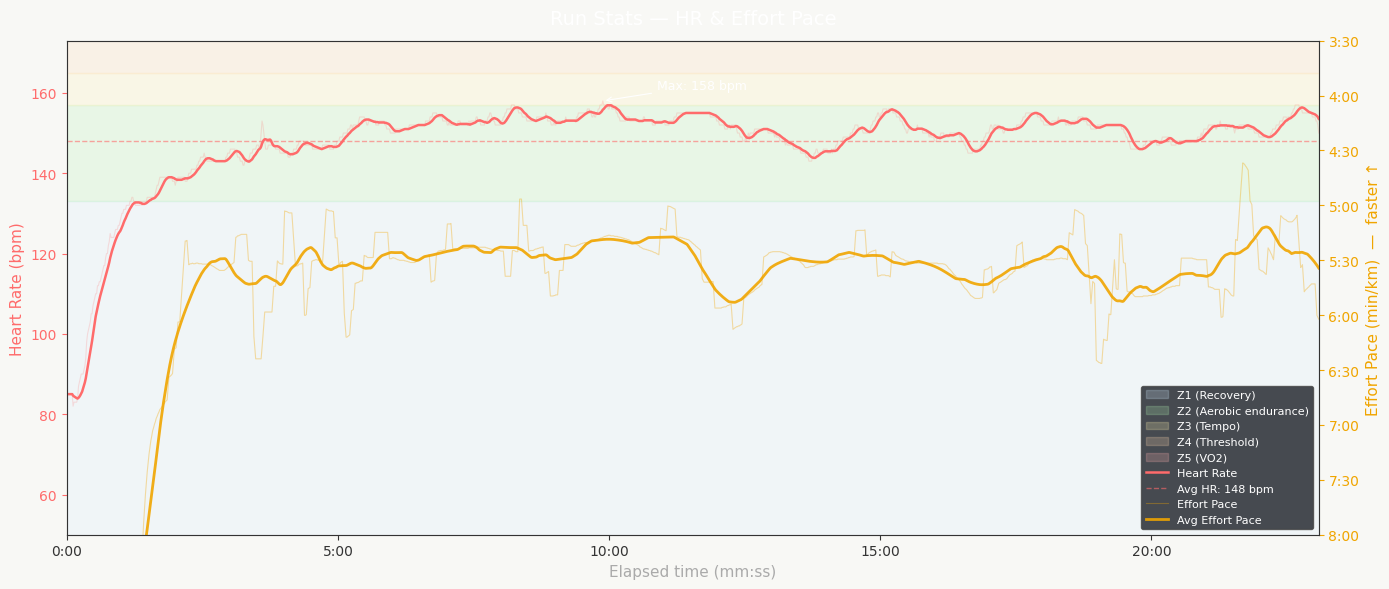

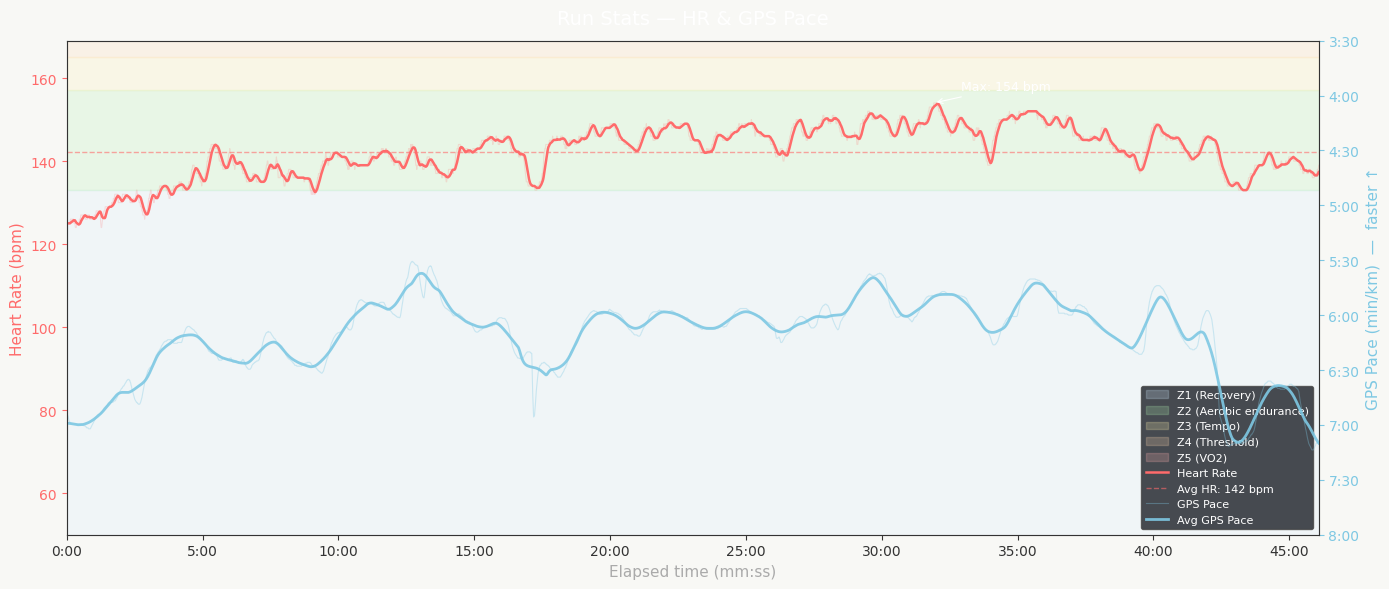

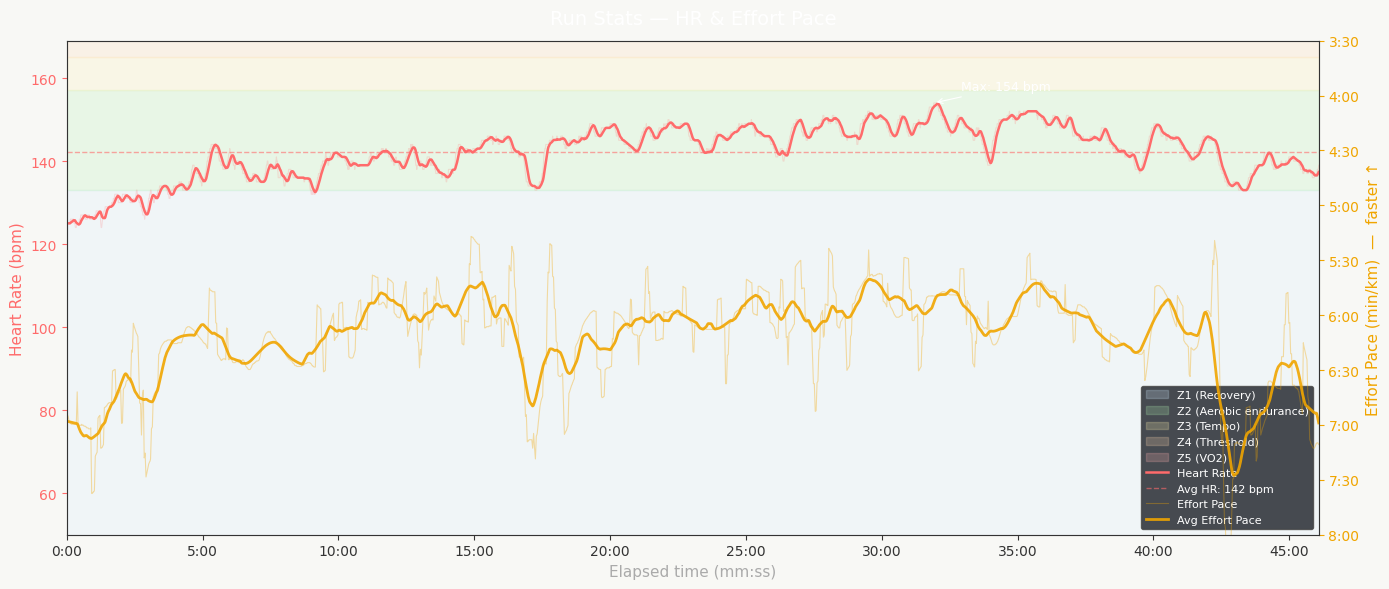

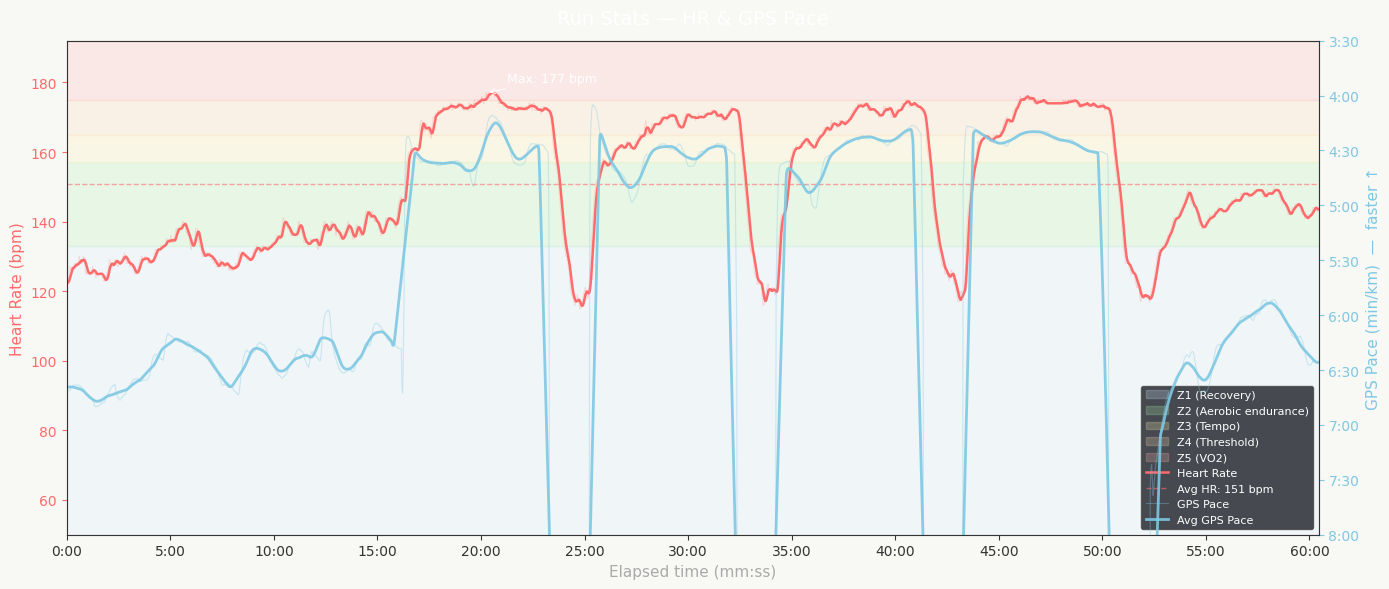

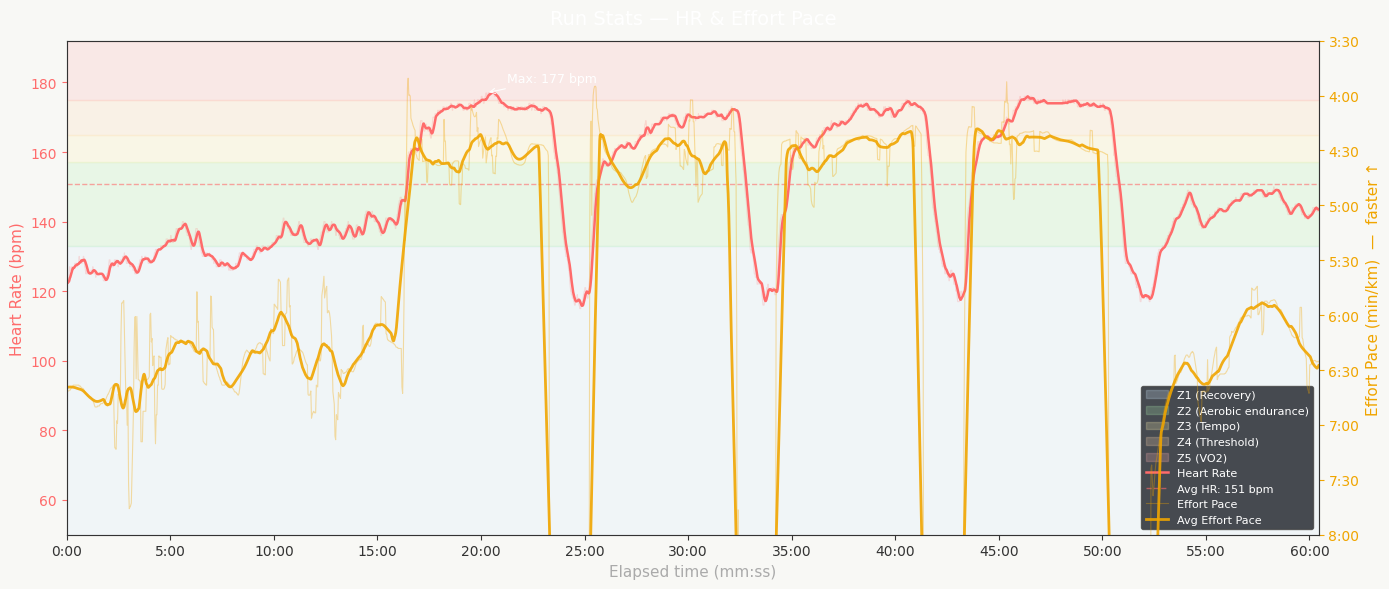

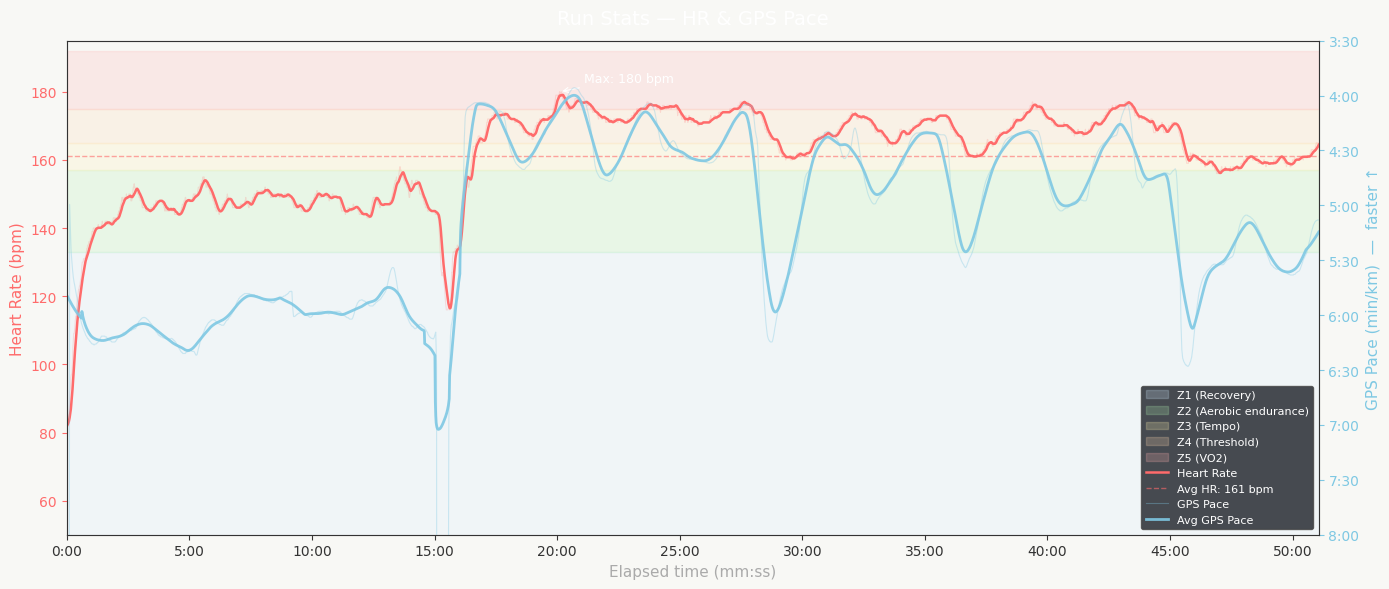

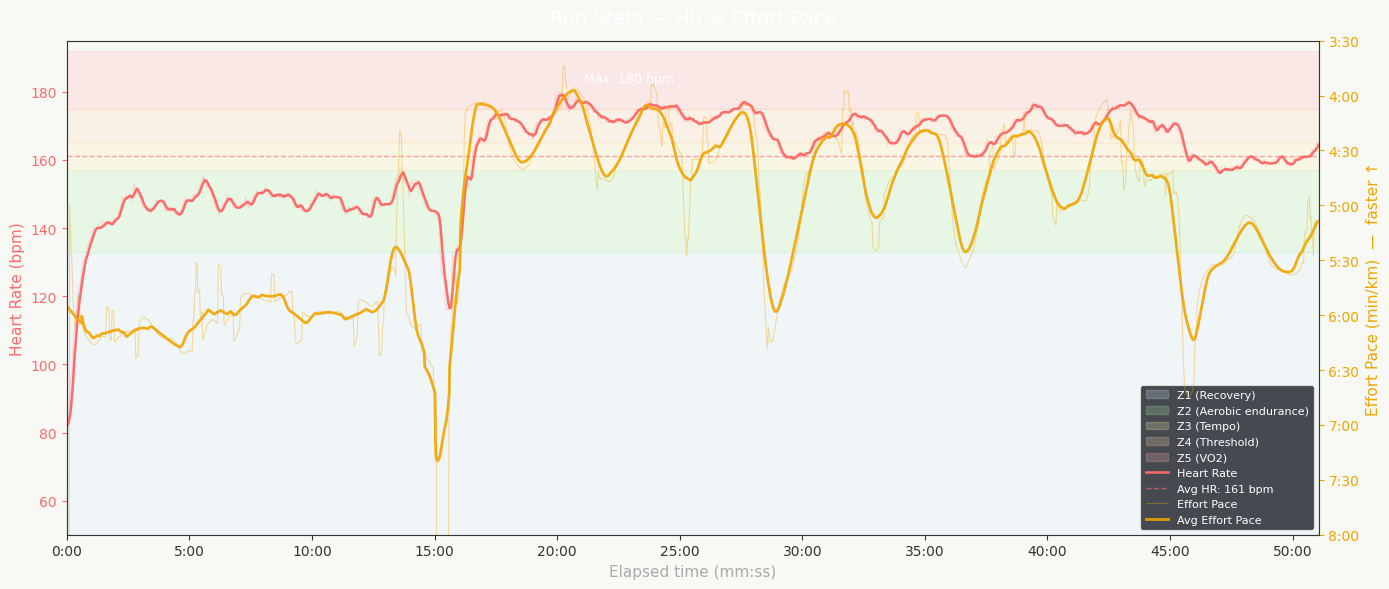

In [132]:
for f in fit_files:
    plot_run_stats(f)
    plot_effortrun_stats(f)


### 2.4 — Cross-correlation: estimate τ\* per file

`cross_correlate_hr_pace()` computes the normalised cross-correlation
$R_{HR,pace}(\tau)$ between HR and a pace series, **using the averaged metrics
from Section 2.2 by default** (pass `use_averaged=False` to correlate against
raw pace instead).

Positive pace is negated before correlating (`use_negative_pace=True`) so that
"faster pace → higher HR" shows up as a *positive* correlation, which is more
intuitive to read. τ\* is the lag (seconds) that maximises $R(\tau)$: a positive
τ\* means HR lags pace by that many seconds.

Results are cached in `TAU_STAR_GPS` / `TAU_STAR_EFFORT` (keyed by file path) so
Section 3 can reuse them for the τ\*-corrected scatter plots.


In [133]:
TAU_STAR_GPS = {}      # fit_path -> tau* (seconds), GPS pace vs HR
TAU_STAR_EFFORT = {}   # fit_path -> tau* (seconds), effort pace vs HR


def cross_correlate_hr_pace(fit_path, pace_key="gps_pace_avg", max_lag_seconds=120,
                            use_negative_pace=True, plot=True):
    '''
    Compute the normalised cross-correlation R_HR,pace(tau) for one file and
    return the lag tau* that maximises it.

    Args:
        fit_path         : key into file_metrics
        pace_key         : which series to correlate against HR
                            ('gps_pace_avg' / 'effort_pace_avg' / 'gps_pace' / 'effort_pace')
        max_lag_seconds  : search/display range for tau, in seconds
        use_negative_pace: negate pace so faster pace = higher signal (recommended)
        plot             : whether to draw R(tau) vs tau

    Returns:
        (tau_star, lag_seconds, corr) or None if insufficient data
    '''
    m = file_metrics[fit_path]
    elapsed = m["elapsed"]
    hr_raw = m["hr"]
    pace_raw = m[pace_key]

    # Keep only timestamps where both HR and the chosen pace series are valid
    pairs = [(e, h, p) for e, h, p in zip(elapsed, hr_raw, pace_raw) if p is not None]
    if len(pairs) < 10:
        print(f"{fit_path}: insufficient data for cross-correlation")
        return None

    elapsed_v, hr_v, pace_v = zip(*pairs)
    hr = np.asarray(hr_v, dtype=float)
    pace = np.asarray(pace_v, dtype=float)
    if use_negative_pace:
        pace = -pace

    hr = hr - hr.mean()
    pace = pace - pace.mean()

    corr = np.correlate(hr, pace, mode="full")
    norm = np.sqrt(np.sum(hr**2) * np.sum(pace**2))
    if norm == 0:
        print(f"{fit_path}: zero-variance signal, cannot correlate")
        return None
    corr = corr / norm

    lags = np.arange(-len(hr) + 1, len(hr))
    dt = np.median(np.diff(elapsed_v))
    lag_seconds = lags * dt

    mask = (lag_seconds >= -max_lag_seconds) & (lag_seconds <= max_lag_seconds)
    lag_seconds_m = lag_seconds[mask]
    corr_m = corr[mask]

    idx_max = np.argmax(corr_m)
    tau_star = lag_seconds_m[idx_max]
    r_max = corr_m[idx_max]

    print(f"{fit_path}\n  pace_key = {pace_key}  |  \u03c4* = {tau_star:.1f} s  |  R_max = {r_max:.3f}")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4.5))
        apply_dark_style(ax, fig)
        ax.plot(lag_seconds_m, corr_m, color="#00e5ff", linewidth=2)
        ax.axvline(tau_star, color="white", linestyle="--", linewidth=1.5,
                   label=f"\u03c4* = {tau_star:.1f} s")
        ax.axhline(0, color="#666666", linewidth=1)
        ax.set_xlabel("Lag \u03c4 (s)", color="#aaaaaa")
        ax.set_ylabel("R(\u03c4)", color="#aaaaaa")
        ax.set_title(f"HR vs {pace_key} cross-correlation", color="white", fontsize=12)
        ax.legend(facecolor="#1c1f26", edgecolor="#444444", labelcolor="white")
        plt.tight_layout()
        plt.show()

    return tau_star, lag_seconds_m, corr_m


In [134]:
max_lag_seconds = 120

for f in fit_files:
    result_gps = cross_correlate_hr_pace(f, pace_key="gps_pace_avg",
                                         max_lag_seconds=max_lag_seconds, plot=False)
    if result_gps is not None:
        TAU_STAR_GPS[f] = result_gps[0]

    result_effort = cross_correlate_hr_pace(f, pace_key="effort_pace_avg",
                                            max_lag_seconds=max_lag_seconds, plot=False)
    if result_effort is not None:
        TAU_STAR_EFFORT[f] = result_effort[0]

print("\nSummary:")
for f in fit_files:
    print(f"  {f}")
    print(f"    \u03c4* (GPS pace)    = {TAU_STAR_GPS.get(f, 'n/a')}")
    print(f"    \u03c4* (Effort pace) = {TAU_STAR_EFFORT.get(f, 'n/a')}")


C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Nantes_6k_tres_lent_2026_08_05.fit
  pace_key = gps_pace_avg  |  τ* = 16.0 s  |  R_max = 0.646
C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\Nantes_6k_tres_lent_2026_08_05.fit
  pace_key = effort_pace_avg  |  τ* = 4.0 s  |  R_max = 0.749
C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\VMA_3_SG_2026_08_07.fit
  pace_key = gps_pace_avg  |  τ* = 34.0 s  |  R_max = 0.842
C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\VMA_3_SG_2026_08_07.fit
  pace_key = effort_pace_avg  |  τ* = 32.0 s  |  R_max = 0.844
C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_progressif_2026_08_09.fit
  pace_key = gps_pace_avg  |  τ* = 0.0 s  |  R_max = 0.870
C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_progressif_2026_08_09.fit
  pace_key = effort_pace_avg  |  τ* = 0.0 s  |  R_max = 0.922
C:\Users\TomDupuis\OneDrive - Oceanwinds\Desktop\Runs\SG_LT2_4×5_2026_08_13.fit
  pace_key = gps_pace_avg  |  τ* = 28.0 s  |  R_max = 

## Section 3 — Pace vs HR scatter plots (all files combined)

These functions combine data from **all files**, apply the abrupt pace-change
filter, optionally shift pace by each file's τ\* (computed in 2.4, using the
**same filtered data**), and plot:
- a density-coloured scatter of (pace, HR)
- mean HR ± 95% CI per pace bin (the `x` markers)

Set `pace_min`, `pace_max`, `pace_bin`, and the abrupt-filter parameters below
before running.


In [135]:
def filter_abrupt_changes(elapsed, hr, pace, abrupt_n=30, abrupt_x=30.0):
    '''
    Discard point i if its pace deviates by more than abrupt_x% from the mean
    pace of the previous abrupt_n *kept* points. Points with fewer than
    abrupt_n valid predecessors are always kept.

    Returns filtered (elapsed, hr, pace) lists.
    '''
    keep = []
    kept_paces = []
    for i in range(len(pace)):
        if len(kept_paces) < abrupt_n:
            keep.append(True)
            kept_paces.append(pace[i])
            continue
        ref = sum(kept_paces[-abrupt_n:]) / abrupt_n
        deviation = abs(pace[i] - ref) / ref * 100.0
        if deviation <= abrupt_x:
            keep.append(True)
            kept_paces.append(pace[i])
        else:
            keep.append(False)

    elapsed_f = [elapsed[i] for i in range(len(elapsed)) if keep[i]]
    hr_f = [hr[i] for i in range(len(hr)) if keep[i]]
    pace_f = [pace[i] for i in range(len(pace)) if keep[i]]
    return elapsed_f, hr_f, pace_f


def shift_series_by_tau(elapsed, values, tau_star):
    '''
    Return values(t - tau_star), interpolated onto the original time grid.
    Positive tau_star means HR lags pace -> pair HR(t) with pace(t - tau_star).
    Points outside the known time range after shifting become NaN.
    '''
    elapsed = np.asarray(elapsed, dtype=float)
    values = np.asarray(values, dtype=float)
    shifted_time = elapsed - tau_star
    return np.interp(shifted_time, elapsed, values, left=np.nan, right=np.nan)


# Palette for per-file colouring — extend if you have more than 10 files
FILE_COLORS = [
    "#aa0e0e", "#db681c", "#dfd402",
    "#7fce25", "#195E12",
    "#080452", "#0c13d2", "#0bcad7",
    "#5D5A61", "#d80584", "#a30566", "#680252", 
    "#e0a38c",
    "#291627"
]


def build_pace_hr_dataset(fit_paths, pace_key="gps_pace", tau_star_lookup=None,
                          apply_tau_correction=False,
                          abrupt_n=10, abrupt_x=20.0,
                          pace_min=3.5, pace_max=6.5):
    '''
    Combine (pace, HR) points from multiple files into flat arrays, after:
      1. dropping timestamps with missing pace
      2. applying the abrupt pace-change filter
      3. optionally shifting pace by each file's tau* (tau_star_lookup[file])
      4. clipping to [pace_min, pace_max]

    Returns:
        paces      : np.ndarray of pace values
        hrs        : np.ndarray of HR values
        file_index : np.ndarray of integer file indices (0 = first file, etc.)
                     — used by the scatter plot to colour points per file.
    '''
    all_paces, all_hrs, all_file_idx = [], [], []

    for file_idx, path in enumerate(fit_paths):
        m = file_metrics[path]
        elapsed = m["elapsed"]
        hr_raw = m["hr"]
        pace_raw = m[pace_key]

        pairs = [(e, h, p) for e, h, p in zip(elapsed, hr_raw, pace_raw) if p is not None]
        if not pairs:
            continue
        e_v, h_v, p_v = map(list, zip(*pairs))

        e_f, h_f, p_f = filter_abrupt_changes(e_v, h_v, p_v,
                                               abrupt_n=abrupt_n, abrupt_x=abrupt_x)

        if apply_tau_correction:
            if tau_star_lookup is None or path not in tau_star_lookup:
                raise ValueError(
                    f"apply_tau_correction=True but no tau* available for {path}. "
                    f"Run Section 2.4 first."
                )
            tau = tau_star_lookup[path]
            p_f = shift_series_by_tau(e_f, p_f, tau)
            valid = ~np.isnan(p_f)
            h_f = np.asarray(h_f)[valid].tolist()
            p_f = p_f[valid].tolist()

        for p, h in zip(p_f, h_f):
            if pace_min <= p <= pace_max:
                all_paces.append(p)
                all_hrs.append(h)
                all_file_idx.append(file_idx)

    return np.array(all_paces), np.array(all_hrs), np.array(all_file_idx, dtype=int)


def _scatter_pace_hr(ax, fig, paces, heart_rates, file_indices, fit_paths,
                     pace_min, pace_max, pace_bin_size):
    '''
    Draw one scatter series per file (each with its own colour from FILE_COLORS),
    then overlay mean HR +/- 95% CI 'x' markers computed across ALL files combined.
    '''
    # ── Per-file scatter ─────────────────────────────────────────────────────
    for file_idx, path in enumerate(fit_paths):
        mask = file_indices == file_idx
        if not mask.any():
            continue
        color =  "#4a90d9" if "Strava Adrien" in path else  FILE_COLORS[file_idx % len(FILE_COLORS)]
        label = path.replace("\\", "/").split("/")[-1].replace(".fit", "")
        ax.scatter(paces[mask], heart_rates[mask],
                   color=color, s=10, alpha=0.45, linewidths=0,
                   zorder=3, label=label)

    # ── Mean HR + 95% CI per pace bin (all files combined) ───────────────────
    bin_edges = np.arange(pace_min, pace_max + pace_bin_size, pace_bin_size)
    bin_indices = np.digitize(paces, bin_edges)

    mean_paces, mean_hrs, ci_errs = [], [], []
    counts = []
    total_counts = 0
    for b in np.unique(bin_indices):
        mask = bin_indices == b
        bucket_hr = heart_rates[mask]
        n = len(bucket_hr)
        if n < 2:
            continue
        mean_paces.append(paces[mask].mean())
        #mean_hrs.append(bucket_hr.mean())
        mean_hrs.append(np.median(bucket_hr))
        ci_errs.append(2.576*bucket_hr.std()/np.sqrt(n))  # 99% CI
        counts.append(n)
        total_counts += n
        print(f"Bin {b}: mean pace = {mean_paces[-1]:.2f}, mean HR = {mean_hrs[-1]:.1f}, n = {n}")

    # Plot number of samples per pace bin
    fig_count, ax_count = plt.subplots(figsize=(10, 4))

    ax_count.plot(
        mean_paces,
        counts,
        marker='o',
        linewidth=1,
        color='tab:blue'
    )

    ax_count.invert_xaxis()
    ax_count.xaxis.set_major_formatter(ticker.FuncFormatter(format_pace))
    ax_count.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax_count.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax_count.yaxis.set_major_locator(ticker.MultipleLocator(250))
    ax_count.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax_count.grid(which="major", color="#272727", linewidth=1.0, linestyle="-", zorder=0)
    ax_count.grid(which="minor", color="#eeeeee", linewidth=0.4, linestyle="-", zorder=0)
    ax_count.set_xlabel("Pace (min/km)")
    ax_count.set_ylabel("Number of samples")
    ax_count.set_title("Samples per pace bin")

    ax_count.grid(True, alpha=0.3)
    plt.tight_layout()

    mean_paces = np.array(mean_paces)
    mean_hrs   = np.array(mean_hrs)
    ci_errs    = np.array(ci_errs)
    order = mean_paces.argsort()
    mean_paces, mean_hrs, ci_errs = mean_paces[order], mean_hrs[order], ci_errs[order]

    ax.errorbar(mean_paces, mean_hrs, yerr=ci_errs,
                fmt="x", color="#111111", markersize=8,
                markeredgewidth=1.5, linewidth=0.6,
                capsize=2, capthick=0.6, alpha=0.85,
                zorder=5, label="Mean HR \u00b1 99% CI")


    return int(heart_rates.max())


def plot_pace_vs_hr_scatter(fit_paths, pace_key="gps_pace", pace_label="GPS Pace",
                            tau_star_lookup=None, apply_tau_correction=False,
                            abrupt_n=10, abrupt_x=20.0,
                            pace_min=3.5, pace_max=6.5, pace_bin=0.1,
                            hr_bin=1,
                            save_path=None):
    '''Build the combined dataset and plot the per-file coloured pace-vs-HR scatter.'''

    paces, hrs, file_indices = build_pace_hr_dataset(
        fit_paths, pace_key=pace_key,
        tau_star_lookup=tau_star_lookup, apply_tau_correction=apply_tau_correction,
        abrupt_n=abrupt_n, abrupt_x=abrupt_x,
        pace_min=pace_min, pace_max=pace_max,
    )

    if len(paces) == 0:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(13, 7))
    apply_dark_style(ax, fig)

    max_hr = _scatter_pace_hr(ax, fig, paces, hrs, file_indices, fit_paths,
                               pace_min, pace_max, pace_bin)

    ax.invert_xaxis()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_pace))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
    ax.grid(which="major", color="#dddddd", linewidth=0.8, linestyle="-", zorder=0)
    ax.grid(which="minor", color="#eeeeee", linewidth=0.4, linestyle="-", zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel(f"{pace_label} (min/km)  \u2190  faster", color="#aaaaaa", fontsize=11)
    ax.set_ylabel("Heart Rate (bpm)", color="#333333", fontsize=11)
    ax.set_ylim(120, max_hr)

    n = len(fit_paths)
    title = f"{pace_label} vs Heart Rate"
    if apply_tau_correction:
        title += " (\u03c4*-corrected)"
    if n > 1:
        title += f" ({n} activities)"
    ax.set_title(title, color="#111111", fontsize=14, pad=14)

    ax.legend(loc="lower right", fontsize=8,
              facecolor="#ffffff", edgecolor="#cccccc", labelcolor="#111111")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved: {save_path}")
    plt.show()

    # =========================================================================
    # Figure 2 — Interactive 3D surface: x=pace, y=HR, z=count of points
    # =========================================================================

    import plotly.graph_objects as go
    import plotly.io as pio

    # Build 2D histogram: bin edges along pace and HR axes
    pace_edges = np.arange(pace_min, pace_max + pace_bin, pace_bin)

    hr_bin = hr_bin   # bpm per HR bin
    hr_edges = np.arange(120, int(hrs.max()) + hr_bin, hr_bin)

    # counts[i, j] = number of points in pace bin i, HR bin j
    counts, _, _ = np.histogram2d(
        paces,
        hrs,
        bins=[pace_edges, hr_edges]
    )

    # Bin centres
    pace_centres = 0.5 * (pace_edges[:-1] + pace_edges[1:])
    hr_centres = 0.5 * (hr_edges[:-1] + hr_edges[1:])

    # Plotly expects:
    # X = pace axis
    # Y = HR axis
    # Z = density
    X, Y = np.meshgrid(
        pace_centres,
        hr_centres,
        indexing="ij"
    )

    # -------------------------------------------------------------------------
    # Normalize HR distribution independently for each pace bin
    # Each pace slice sums to 1:
    #
    # Znorm(pace, HR) = count(pace, HR) / total_count(pace)
    #
    # This represents P(HR | pace)
    # -------------------------------------------------------------------------

    pace_totals = counts.sum(axis=1, keepdims=True)

    # Avoid division by zero for empty pace bins
    Z = np.divide(
        counts,
        pace_totals,
        out=np.zeros_like(counts, dtype=float),
        where=pace_totals != 0
    )

    # Convert pace values to min:ss labels
    pace_labels = [
        f"{int(p)}:{int(round((p % 1) * 60)):02d}"
        for p in pace_centres
    ]

    fig2 = go.Figure(
        data=[
            go.Surface(
                x=X,
                y=Y,
                z=Z,
                colorscale="Viridis",
                opacity=1,
                colorbar=dict(
                    title="Probability<br>P(HR | pace)"
                ),
                hovertemplate=(
                    "Pace: %{x:.2f} min/km<br>"
                    "HR: %{y:.0f} bpm<br>"
                    "Relative density: %{z:.2f}"
                    "<extra></extra>"
                )
            )
        ]
    )

    fig2.update_layout(
        title=dict(
            text=f"{title} — interactive density surface",
            x=0.5
        ),

        scene=dict(

            # Pace axis
            xaxis=dict(
                title=f"{pace_label} (min/km)",
                autorange="reversed",
                tickmode="array",
                tickvals=pace_centres[::5],
                ticktext=pace_labels[::5],
            ),

            # Heart rate axis
            yaxis=dict(
                title="Heart Rate (bpm)"
            ),

            # Density axis
            zaxis=dict(
                title="Number of points"
            ),

            camera=dict(
                eye=dict(
                    x=1.6,
                    y=1.6,
                    z=1.1
                )
            )
        ),

        width=850,
        height=600,
        template="plotly_white"
    )

    # Save if requested
    if save_path:
        fig2.write_html(
            save_path.replace(".png", "_density3d.html")
        )

    # Opens an interactive browser view in VSCode/Jupyter
    fig2.show()


    # =========================================================================
    # Figure 3 — Scatter coloured by shape-normalized density
    # =========================================================================

    import matplotlib.colors as mcolors

    # -------------------------------------------------------------------------
    # Shape scaling normalization per pace bin:
    #
    # Znorm(pace, HR) = (count - min(count)) / (max(count)-min(count))
    #
    # -------------------------------------------------------------------------

    Znorm = np.zeros_like(counts, dtype=float)

    for i in range(counts.shape[0]):

        pace_profile = counts[i, :]

        z_min = pace_profile.min()
        z_max = pace_profile.max()

        if z_max > z_min:
            Znorm[i, :] = (
                (pace_profile - z_min)
                /
                (z_max - z_min)
            )


    # -------------------------------------------------------------------------
    # Assign normalized density value to every scatter point
    # -------------------------------------------------------------------------

    pace_idx = np.digitize(paces, pace_edges) - 1
    hr_idx = np.digitize(hrs, hr_edges) - 1

    valid = (
        (pace_idx >= 0) &
        (pace_idx < Znorm.shape[0]) &
        (hr_idx >= 0) &
        (hr_idx < Znorm.shape[1])
    )

    point_density = np.zeros_like(paces, dtype=float)

    point_density[valid] = Znorm[
        pace_idx[valid],
        hr_idx[valid]
    ]


    # =========================================================================
    # Plot Figure 3
    # =========================================================================

    fig3, ax3 = plt.subplots(figsize=(13, 7))
    apply_dark_style(ax3, fig3)

    scatter3 = ax3.scatter(
        paces,
        hrs,
        c=point_density,
        cmap="viridis",
        s=10,
        alpha=0.55,
        linewidths=0
    )


    # -------------------------------------------------------------------------
    # Median HR crosses per pace bin
    # -------------------------------------------------------------------------

    median_pace = []
    median_hr = []

    for i in range(len(pace_edges)-1):

        mask = (
            (paces >= pace_edges[i]) &
            (paces < pace_edges[i+1])
        )

        if np.any(mask):

            median_pace.append(
                0.5 * (pace_edges[i] + pace_edges[i+1])
            )

            median_hr.append(
                np.median(hrs[mask])
            )


    ax3.scatter(
        median_pace,
        median_hr,
        marker="x",
        c="black",
        s=70,
        linewidths=2,
        label="Median HR"
    )


    # Same formatting as Figure 1

    ax3.invert_xaxis()
    ax3.xaxis.set_major_formatter(ticker.FuncFormatter(format_pace))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax3.yaxis.set_minor_locator(ticker.MultipleLocator(5))
    ax3.grid(which="major", color="#dddddd", linewidth=0.8, linestyle="-", zorder=0)
    ax3.grid(which="minor", color="#eeeeee", linewidth=0.4, linestyle="-", zorder=0)
    ax3.set_axisbelow(True)

    ax3.set_xlabel(
        f"{pace_label} (min/km)  \u2190  faster",
        color="#aaaaaa",
        fontsize=11
    )

    ax3.set_ylabel(
        "Heart Rate (bpm)",
        color="#333333",
        fontsize=11
    )

    ax3.set_ylim(120, max(hrs))

    ax3.set_title(
        f"{title} — shape-normalized density scatter",
        color="#111111",
        fontsize=14,
        pad=14
    )


    cbar = fig3.colorbar(
        scatter3,
        ax=ax3
    )

    cbar.set_label(
        "Relative density (shape normalized)",
        fontsize=10
    )


    ax3.legend(
        loc="lower right",
        fontsize=8,
        facecolor="#ffffff",
        edgecolor="#cccccc",
        labelcolor="#111111"
    )


    plt.tight_layout()

    if save_path:
        fig3.savefig(
            save_path.replace(".png", "_density_scatter.png"),
            dpi=150,
            bbox_inches="tight",
            facecolor=fig3.get_facecolor()
        )

    plt.show()

With τ* correction:
Bin 1: mean pace = 3.51, mean HR = 174.0, n = 30
Bin 2: mean pace = 3.58, mean HR = 166.0, n = 21
Bin 3: mean pace = 3.67, mean HR = 176.0, n = 44
Bin 4: mean pace = 3.76, mean HR = 178.0, n = 124
Bin 5: mean pace = 3.83, mean HR = 178.5, n = 178
Bin 6: mean pace = 3.92, mean HR = 177.0, n = 234
Bin 7: mean pace = 3.99, mean HR = 178.5, n = 350
Bin 8: mean pace = 4.08, mean HR = 175.0, n = 455
Bin 9: mean pace = 4.17, mean HR = 174.0, n = 367
Bin 10: mean pace = 4.26, mean HR = 173.0, n = 367
Bin 11: mean pace = 4.34, mean HR = 173.0, n = 749
Bin 12: mean pace = 4.41, mean HR = 172.0, n = 726
Bin 13: mean pace = 4.50, mean HR = 171.0, n = 512
Bin 14: mean pace = 4.59, mean HR = 170.0, n = 565
Bin 15: mean pace = 4.66, mean HR = 170.0, n = 421
Bin 16: mean pace = 4.75, mean HR = 170.0, n = 373
Bin 17: mean pace = 4.83, mean HR = 166.0, n = 273
Bin 18: mean pace = 4.92, mean HR = 168.0, n = 192
Bin 19: mean pace = 5.00, mean HR = 168.0, n = 228
Bin 20: mean pace = 5.0

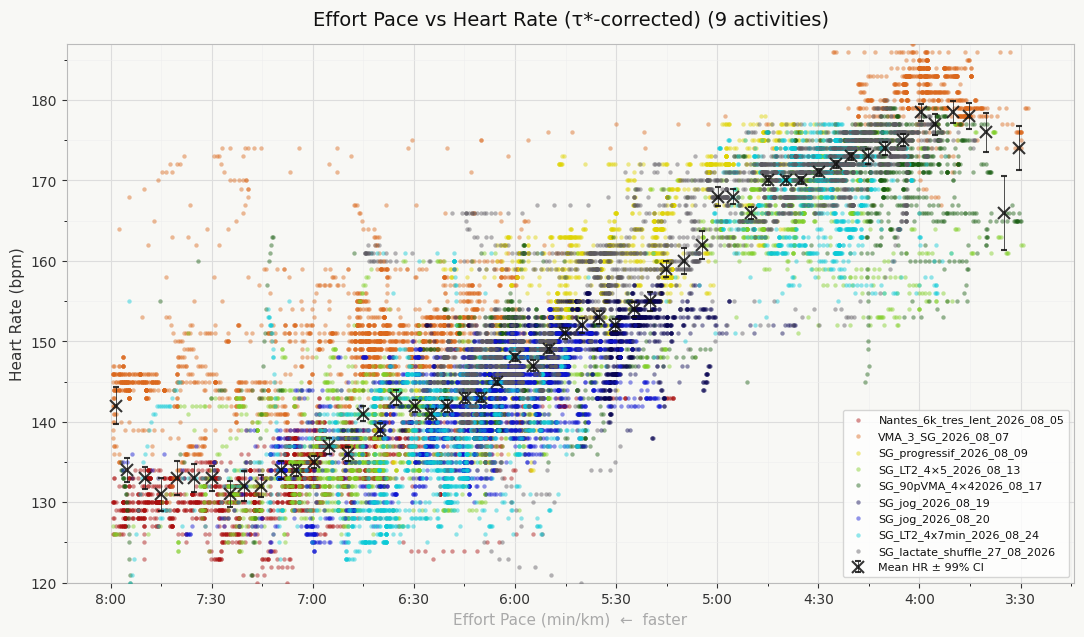

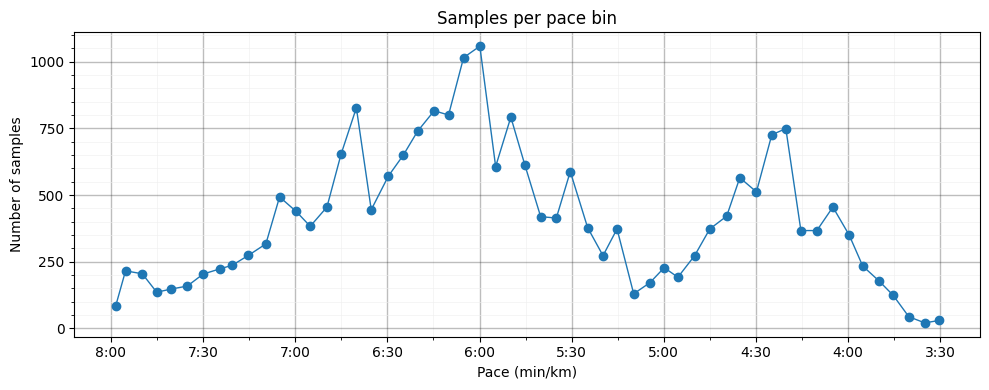

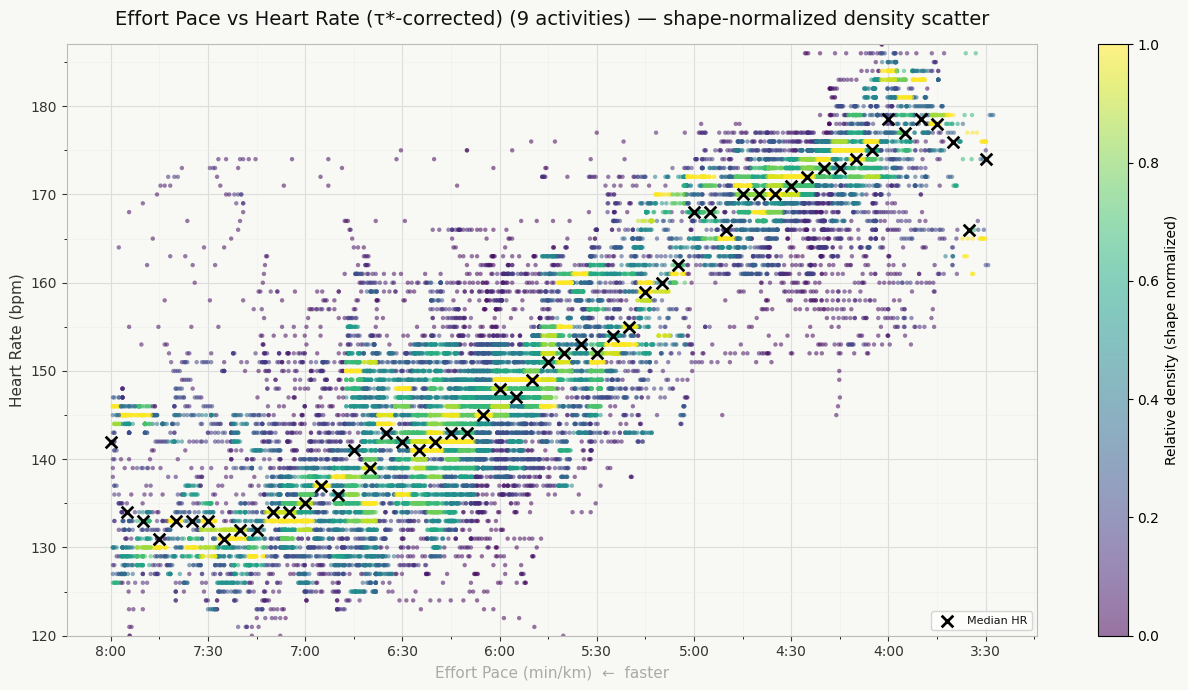

In [136]:
# ── Scatter plot parameters — adjust as needed ──────────────────────────────
pace_min = 3.5- 1/24
pace_max = 8
pace_bin = 1/12
abrupt_n = 30
abrupt_x = 100.0   # set lower (e.g. 20.0) to actively filter abrupt pace changes
# ─────────────────────────────────────────────────────────────────────────────

print("With \u03c4* correction:")

# plot_pace_vs_hr_scatter(fit_files, pace_key="gps_pace", pace_label="GPS Pace",
#                         tau_star_lookup=TAU_STAR_GPS, apply_tau_correction=True,
#                         abrupt_n=abrupt_n, abrupt_x=abrupt_x,
#                         pace_min=pace_min, pace_max=pace_max, pace_bin=pace_bin)    

plot_pace_vs_hr_scatter(fit_files, pace_key="effort_pace", pace_label="Effort Pace",
                        tau_star_lookup=TAU_STAR_EFFORT, apply_tau_correction=True,
                        abrupt_n=abrupt_n, abrupt_x=abrupt_x,
                        pace_min=pace_min, pace_max=pace_max, pace_bin=pace_bin)
